In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist


In [2]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from tqdm import tqdm

def identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10):
    # Get coordinates and cell types
    spatial_coords_x = adata.obs['X'].astype(float)
    spatial_coords_y = adata.obs['Y'].astype(float)
    spatial_coords = np.array(list(zip(spatial_coords_x, spatial_coords_y)))
    cell_types = adata.obs['cell_type'].astype(int)

    # Set up plot
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(spatial_coords[:, 0], spatial_coords[:, 1], s=10, label='All Cells', color='gray', alpha=0.5)
    ax.scatter(spatial_coords[cell_types == tumor_cell_type, 0], spatial_coords[cell_types == tumor_cell_type, 1], 
               s=10, label='Tumor Cells (cell_type=1)', color='red')

    # Iterate over cells of type 2 to find bag centers
    for i in tqdm(range(len(spatial_coords)), desc="Identifying bag centers", ncols=100):
        if cell_types[i] != center_cell_type:
            continue  # Skip cells that are not candidate centers

        # Calculate distances to all other points
        distances = cdist([spatial_coords[i]], spatial_coords, metric='euclidean')[0]
        
        # Find neighbors within the radius
        neighbors = np.where(distances <= radius)[0]
        
        # Filter for tumor cells within the radius
        tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
        
        # If there are enough tumor cells in the neighborhood, mark as a bag center
        if len(tumor_neighbors) >= min_tumor_neighbors:
            ax.scatter(spatial_coords[i, 0], spatial_coords[i, 1], s=50, edgecolor='black', facecolor='yellow', 
                       label='Bag Center' if i == 0 else "")

    # Finalize plot
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")               
    ax.legend()
    plt.title(f"Bag Centers and Tumor Cells")
    plt.show()


In [ ]:

# Load the H5AD file
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/merscope_data/HumanBreastCancerPatient1/T_cell.h5ad")

# Call the function
identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)


Identifying bag centers:   0%|                                           | 0/561302 [00:00<?, ?it/s]/tmp/ipykernel_71169/921936570.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if cell_types[i] != center_cell_type:
/tmp/ipykernel_71169/921936570.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
Identifying bag centers: 100%|███████████████████████████| 561302/561302 [00:38<00:00, 14537.39it/s]
/work/DPDS/s439765/envs/spatial_tcr/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc=

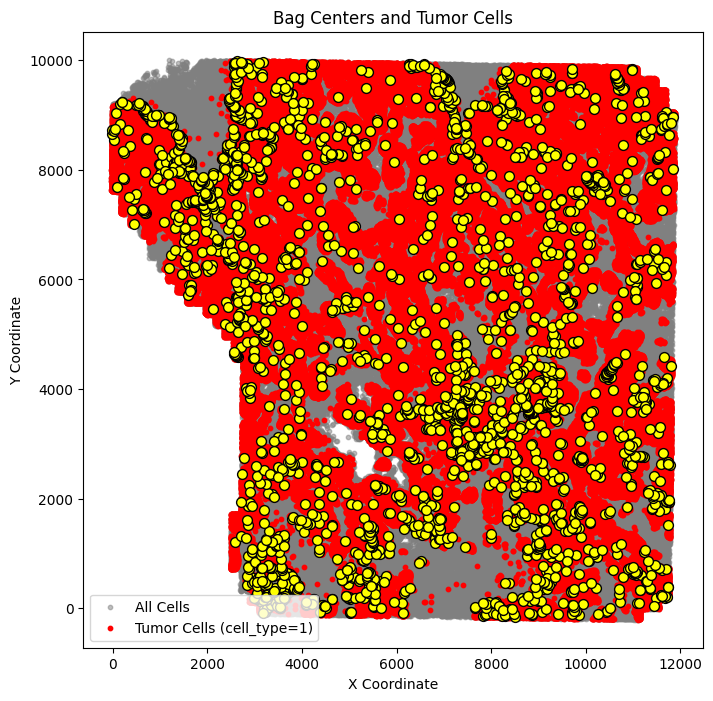

In [14]:
# Load the H5AD file
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/merscope_data/HumanBreastCancerPatient1/T_cell.h5ad")

identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)


Identifying bag centers:   0%|                                           | 0/674392 [00:00<?, ?it/s]/tmp/ipykernel_71169/921936570.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if cell_types[i] != center_cell_type:
/tmp/ipykernel_71169/921936570.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
Identifying bag centers: 100%|███████████████████████████| 674392/674392 [00:33<00:00, 20214.34it/s]


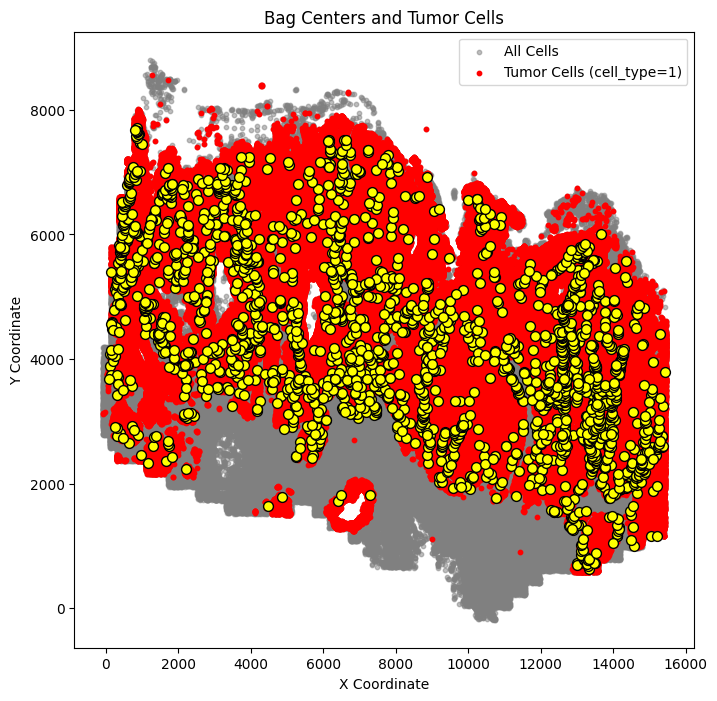

In [15]:

# Load the H5AD file
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/merscope_data/HumanColonCancerPatient2/T_cell.h5ad")

identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)


Identifying bag centers:   0%|                                           | 0/414452 [00:00<?, ?it/s]/tmp/ipykernel_71169/921936570.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if cell_types[i] != center_cell_type:
/tmp/ipykernel_71169/921936570.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
Identifying bag centers: 100%|███████████████████████████| 414452/414452 [00:33<00:00, 12254.14it/s]
/work/DPDS/s439765/envs/spatial_tcr/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc=

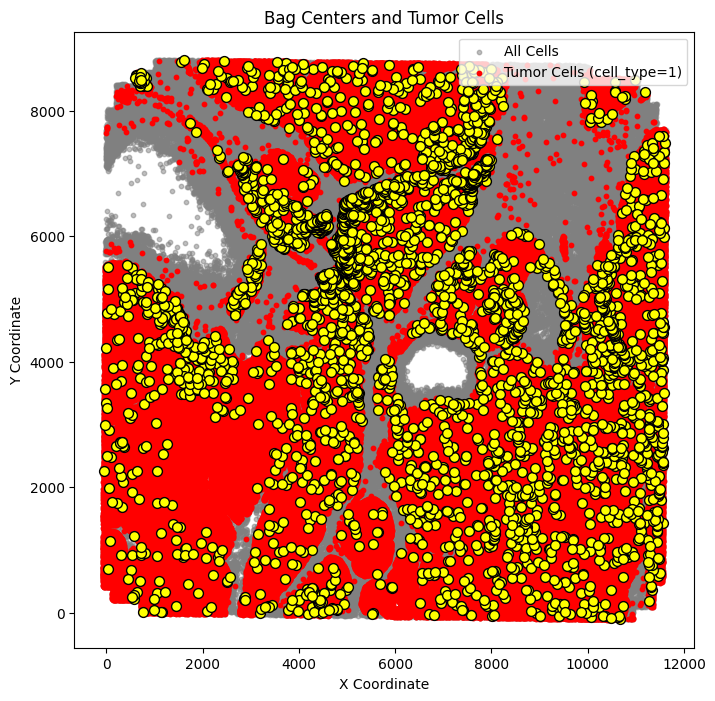

In [16]:

# Load the H5AD file
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/merscope_data/HumanLiverCancerPatient1/T_cell.h5ad")

identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)


Identifying bag centers:   0%|                                           | 0/486926 [00:00<?, ?it/s]/tmp/ipykernel_71169/921936570.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if cell_types[i] != center_cell_type:
/tmp/ipykernel_71169/921936570.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
Identifying bag centers: 100%|███████████████████████████| 486926/486926 [00:13<00:00, 35154.45it/s]


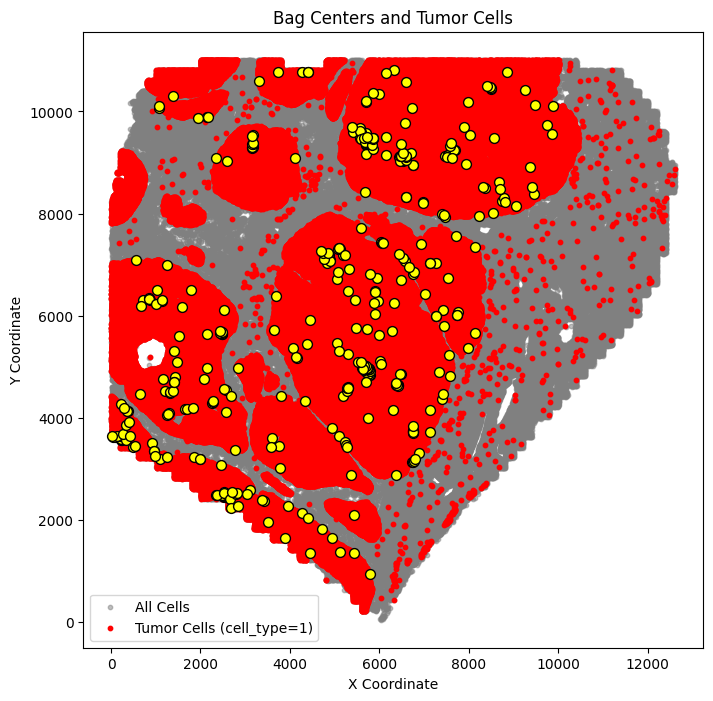

In [17]:

# Load the H5AD file
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/merscope_data/HumanLiverCancerPatient2/T_cell.h5ad")

identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)


Identifying bag centers:   0%|                                           | 0/655744 [00:00<?, ?it/s]/tmp/ipykernel_71169/921936570.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if cell_types[i] != center_cell_type:
/tmp/ipykernel_71169/921936570.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
Identifying bag centers: 100%|████████████████████████████| 655744/655744 [10:17<00:00, 1062.60it/s]
/work/DPDS/s439765/envs/spatial_tcr/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc=

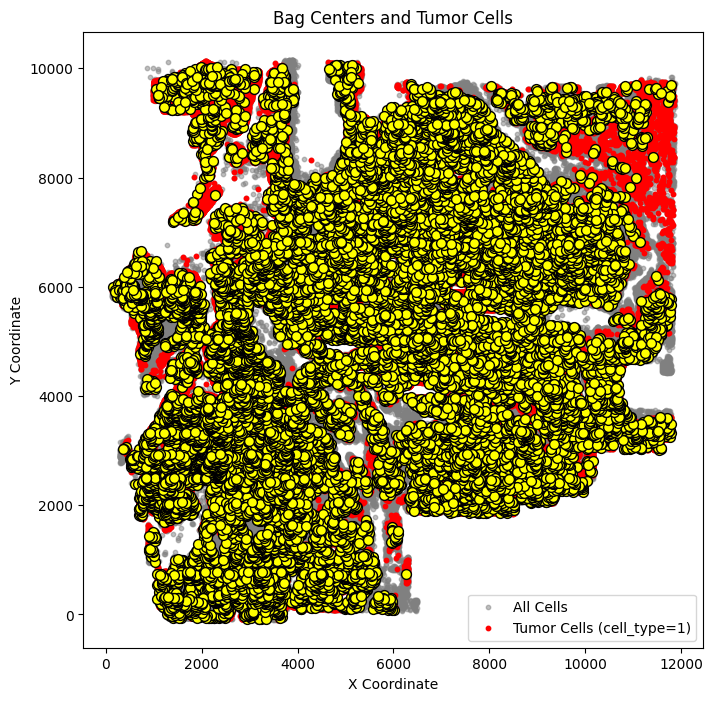

In [18]:

# Load the H5AD file
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/merscope_data/HumanLungCancerPatient2/T_cell.h5ad")

identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)


Identifying bag centers:   0%|                                           | 0/366575 [00:00<?, ?it/s]/tmp/ipykernel_71169/921936570.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if cell_types[i] != center_cell_type:
/tmp/ipykernel_71169/921936570.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
Identifying bag centers: 100%|███████████████████████████| 366575/366575 [00:25<00:00, 14102.91it/s]


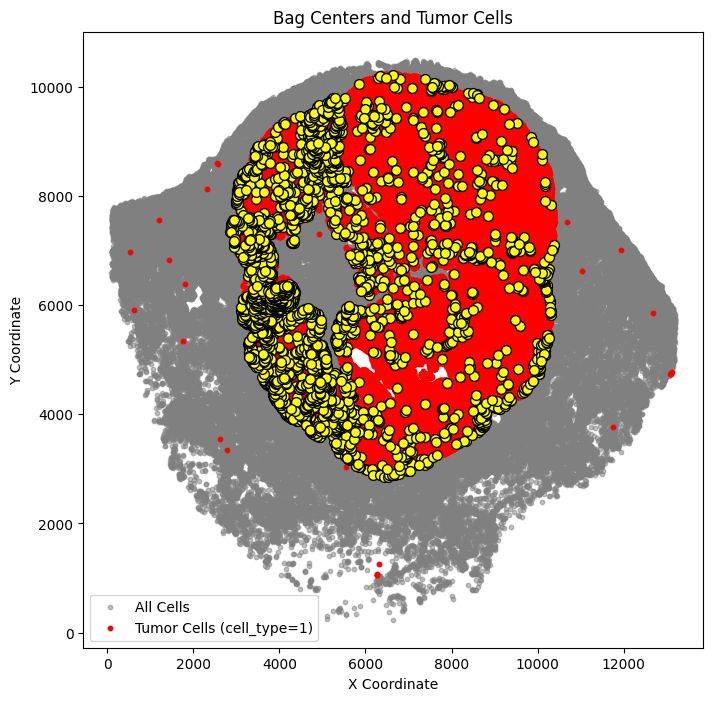

In [19]:
# Load the H5AD file
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/merscope_data/HumanMelanomaPatient1/T_cell.h5ad")

identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)


Identifying bag centers:   0%|                                           | 0/143957 [00:00<?, ?it/s]/tmp/ipykernel_71169/921936570.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if cell_types[i] != center_cell_type:
/tmp/ipykernel_71169/921936570.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
Identifying bag centers: 100%|████████████████████████████| 143957/143957 [00:14<00:00, 9773.58it/s]


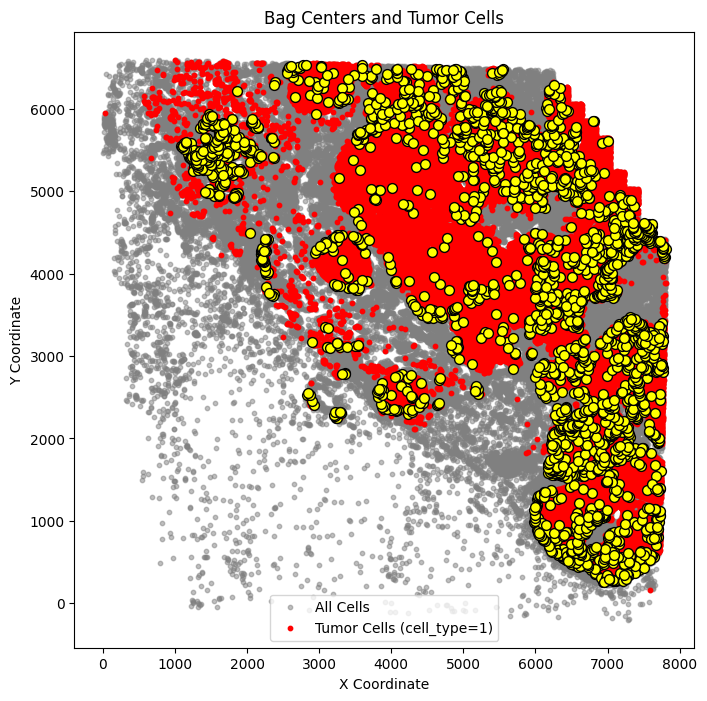

In [20]:
# Load the H5AD file
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/merscope_data/HumanMelanomaPatient2/T_cell.h5ad")

identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)


Identifying bag centers:   0%|                                           | 0/322903 [00:00<?, ?it/s]/tmp/ipykernel_71169/921936570.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if cell_types[i] != center_cell_type:
/tmp/ipykernel_71169/921936570.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
Identifying bag centers: 100%|███████████████████████████| 322903/322903 [00:08<00:00, 35975.21it/s]


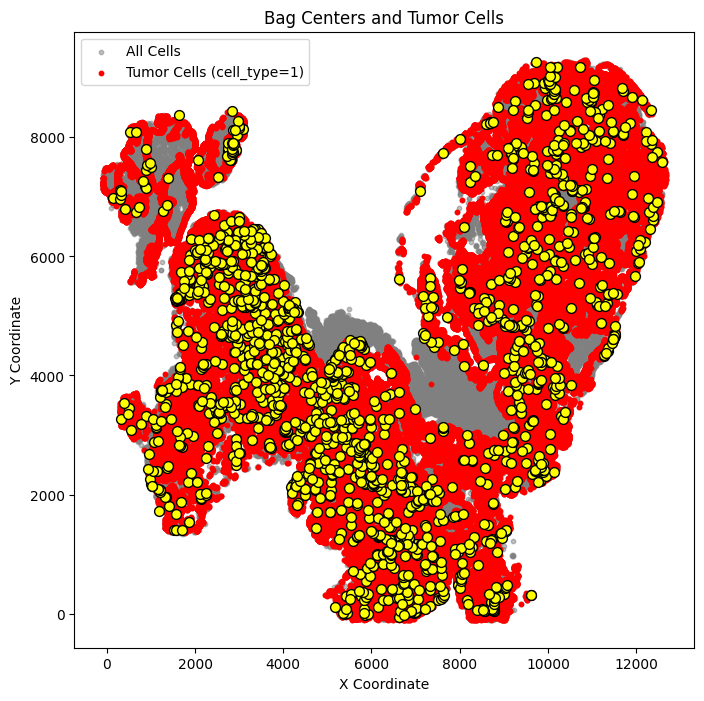

In [21]:
# Load the H5AD file
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/merscope_data/HumanOvarianCancerPatient1/T_cell.h5ad")

identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)


Identifying bag centers:   0%|                                           | 0/215414 [00:00<?, ?it/s]/tmp/ipykernel_71169/921936570.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if cell_types[i] != center_cell_type:
/tmp/ipykernel_71169/921936570.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
Identifying bag centers: 100%|███████████████████████████| 215414/215414 [00:02<00:00, 77055.80it/s]


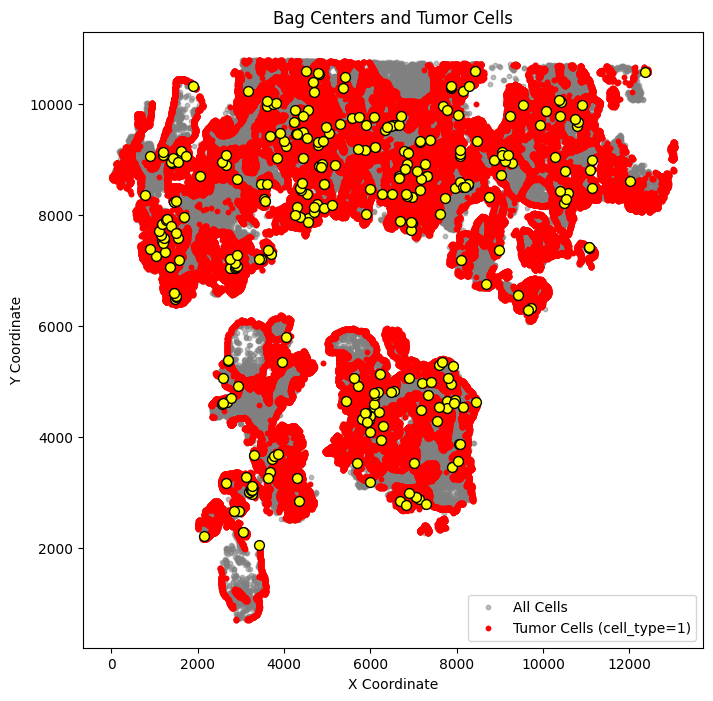

In [22]:
# Load the H5AD file
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/merscope_data/HumanOvarianCancerPatient2Slice1/T_cell.h5ad")

identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)


Identifying bag centers:   0%|                                           | 0/544666 [00:00<?, ?it/s]/tmp/ipykernel_71169/921936570.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if cell_types[i] != center_cell_type:
/tmp/ipykernel_71169/921936570.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
Identifying bag centers: 100%|███████████████████████████| 544666/544666 [00:37<00:00, 14698.51it/s]


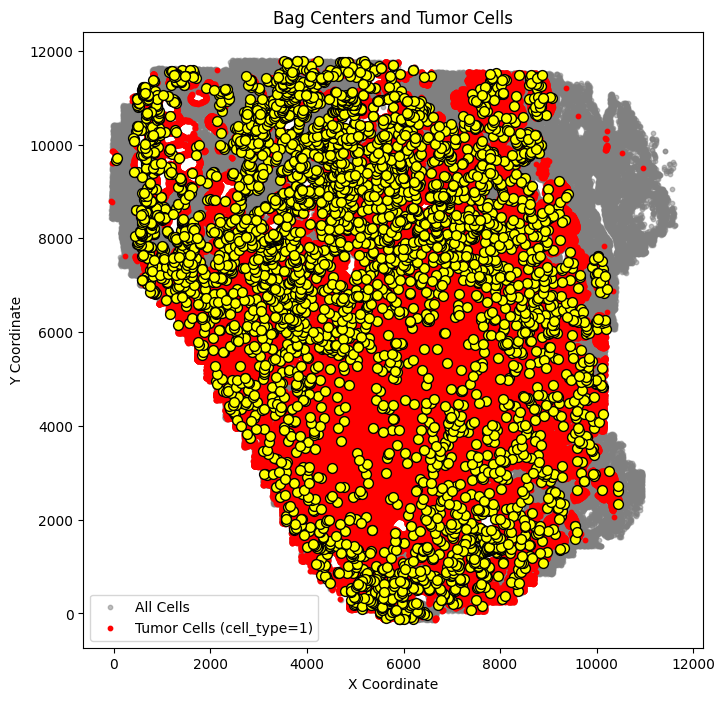

In [23]:
# Load the H5AD file
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/merscope_data/HumanProstateCancerPatient1/T_cell.h5ad")

identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)


Identifying bag centers:   0%|                                           | 0/574794 [00:00<?, ?it/s]/tmp/ipykernel_71169/921936570.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if cell_types[i] != center_cell_type:
/tmp/ipykernel_71169/921936570.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
Identifying bag centers:   8%|██▎                         | 48710/574794 [00:01<00:16, 31992.78it/s]

Identifying bag centers: 100%|███████████████████████████| 574794/574794 [00:18<00:00, 30414.71it/s]
/work/DPDS/s439765/envs/spatial_tcr/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


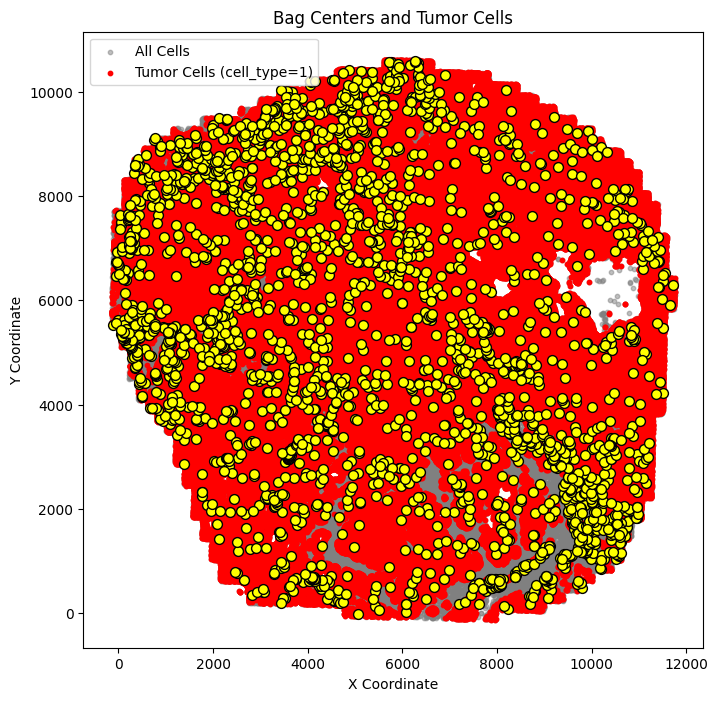

In [24]:
# Load the H5AD file
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/merscope_data/HumanProstateCancerPatient2/T_cell.h5ad")

identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)


Identifying bag centers:   0%|                                           | 0/595131 [00:00<?, ?it/s]/tmp/ipykernel_71169/921936570.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if cell_types[i] != center_cell_type:
/tmp/ipykernel_71169/921936570.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
Identifying bag centers: 100%|███████████████████████████| 595131/595131 [00:11<00:00, 52067.45it/s]


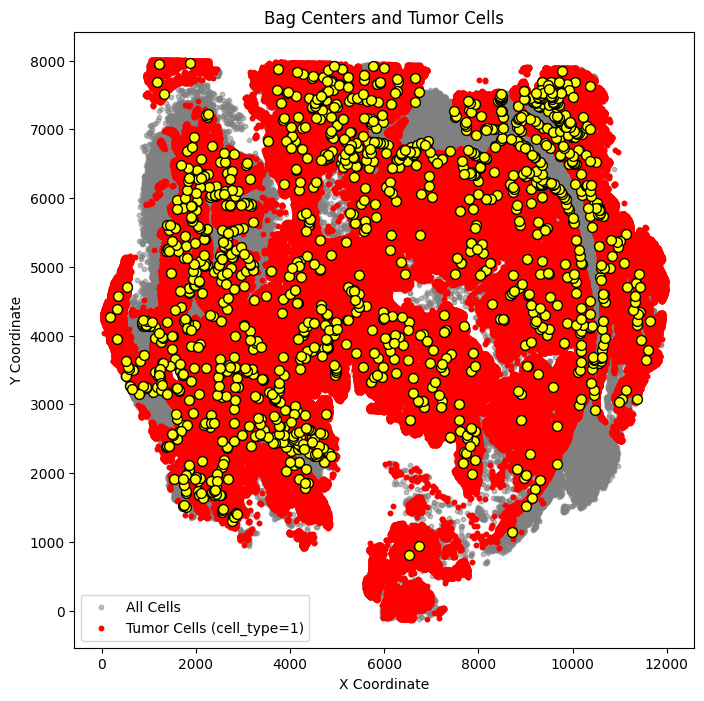

In [28]:
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/spatial_transcriptomics/merscope_data/HumanColonCancerPatient1/T_cell.h5ad")
identify_bag_centers(adata, radius=50, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)



Identifying bag centers:   0%|                                             | 0/2535 [00:00<?, ?it/s]/tmp/ipykernel_27939/2844128541.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if cell_types[i] != center_cell_type:
/tmp/ipykernel_27939/2844128541.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  tumor_neighbors = [idx for idx in neighbors if cell_types[idx] == tumor_cell_type]
Identifying bag centers: 100%|████████████████████████████████| 2535/2535 [00:01<00:00, 1612.53it/s]


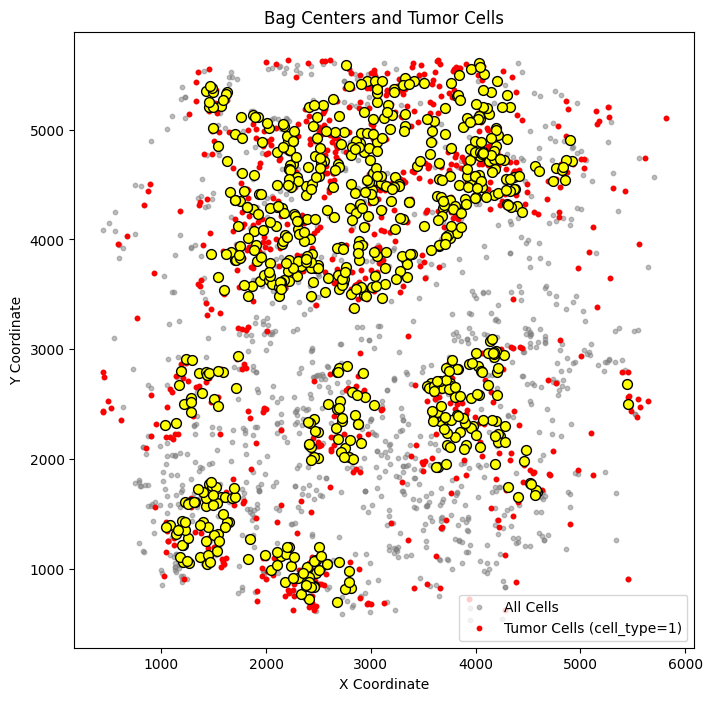

In [32]:
adata = sc.read_h5ad("/project/DPDS/Wang_lab/s439765/spatial_tcr/slide_tag/slide_tag_melanoma_processed.h5ad")
identify_bag_centers(adata, radius=300, tumor_cell_type=1, center_cell_type=2, min_tumor_neighbors=10)


In [23]:
adata.obs

,n_genes,cell_type,T,X,Y
AAACAGCCAACAGGTG-1,1845,2.0,1.0,925.546560,1326.436280
AAACCAACAAGTTATC-1,4009,0.0,0.0,2421.643600,877.297940
AAACCGGCAACTGGGA-1,3729,0.0,0.0,2497.280298,3683.864234
AAACCGGCACTTGTTC-1,1233,2.0,1.0,1726.888000,2944.199500
AAACGCGCAATAAGCA-1,1325,0.0,0.0,4284.474286,4512.109143
...,...,...,...,...,...
TTTGTCTAGGCCCAGT-1,1713,2.0,1.0,4144.480100,4926.740800
TTTGTGAAGTATTGTG-1,3894,1.0,0.0,2500.976826,2116.358870
TTTGTGGCATTATGAC-1,1812,2.0,1.0,4259.394267,896.955867
TTTGTGTTCATAAGCC-1,1336,2.0,1.0,4010.284200,4471.848600


In [26]:
adata.obs[adata.obs['cell_type']==1]


,n_genes,cell_type,T,X,Y
AAAGCAAGTGATGAGG-1,8589,1.0,0.0,3778.685670,2585.060765
AAAGCAAGTTAGCATG-1,3841,1.0,0.0,3943.649800,4533.029900
AAAGCTTGTGCAATGC-1,4027,1.0,0.0,1877.122000,4134.469714
AACATCATCAGGCTAT-1,7033,1.0,0.0,4563.736768,1707.012957
AACCCGCAGGTCGAGG-1,3803,1.0,0.0,3539.026925,863.646221
...,...,...,...,...,...
TTTGGCTGTGCTGGTG-1,5787,1.0,0.0,2585.201143,4809.909325
TTTGGTAAGGGTTATC-1,7337,1.0,0.0,2253.780786,4629.268795
TTTGGTAAGTTATGTG-1,9164,1.0,0.0,5617.432865,4743.697838
TTTGTGAAGTATTGTG-1,3894,1.0,0.0,2500.976826,2116.358870
